Starting visualization process...


Visualizing samples:   0%|          | 0/3 [00:00<?, ?it/s]


--- Processing: malignant_186 ---
Running inference for Baseline Model...
Running inference for Our Model (Adapter + U-BL)...
Visualization saved to: visualizations/00000_comparison_v2.png


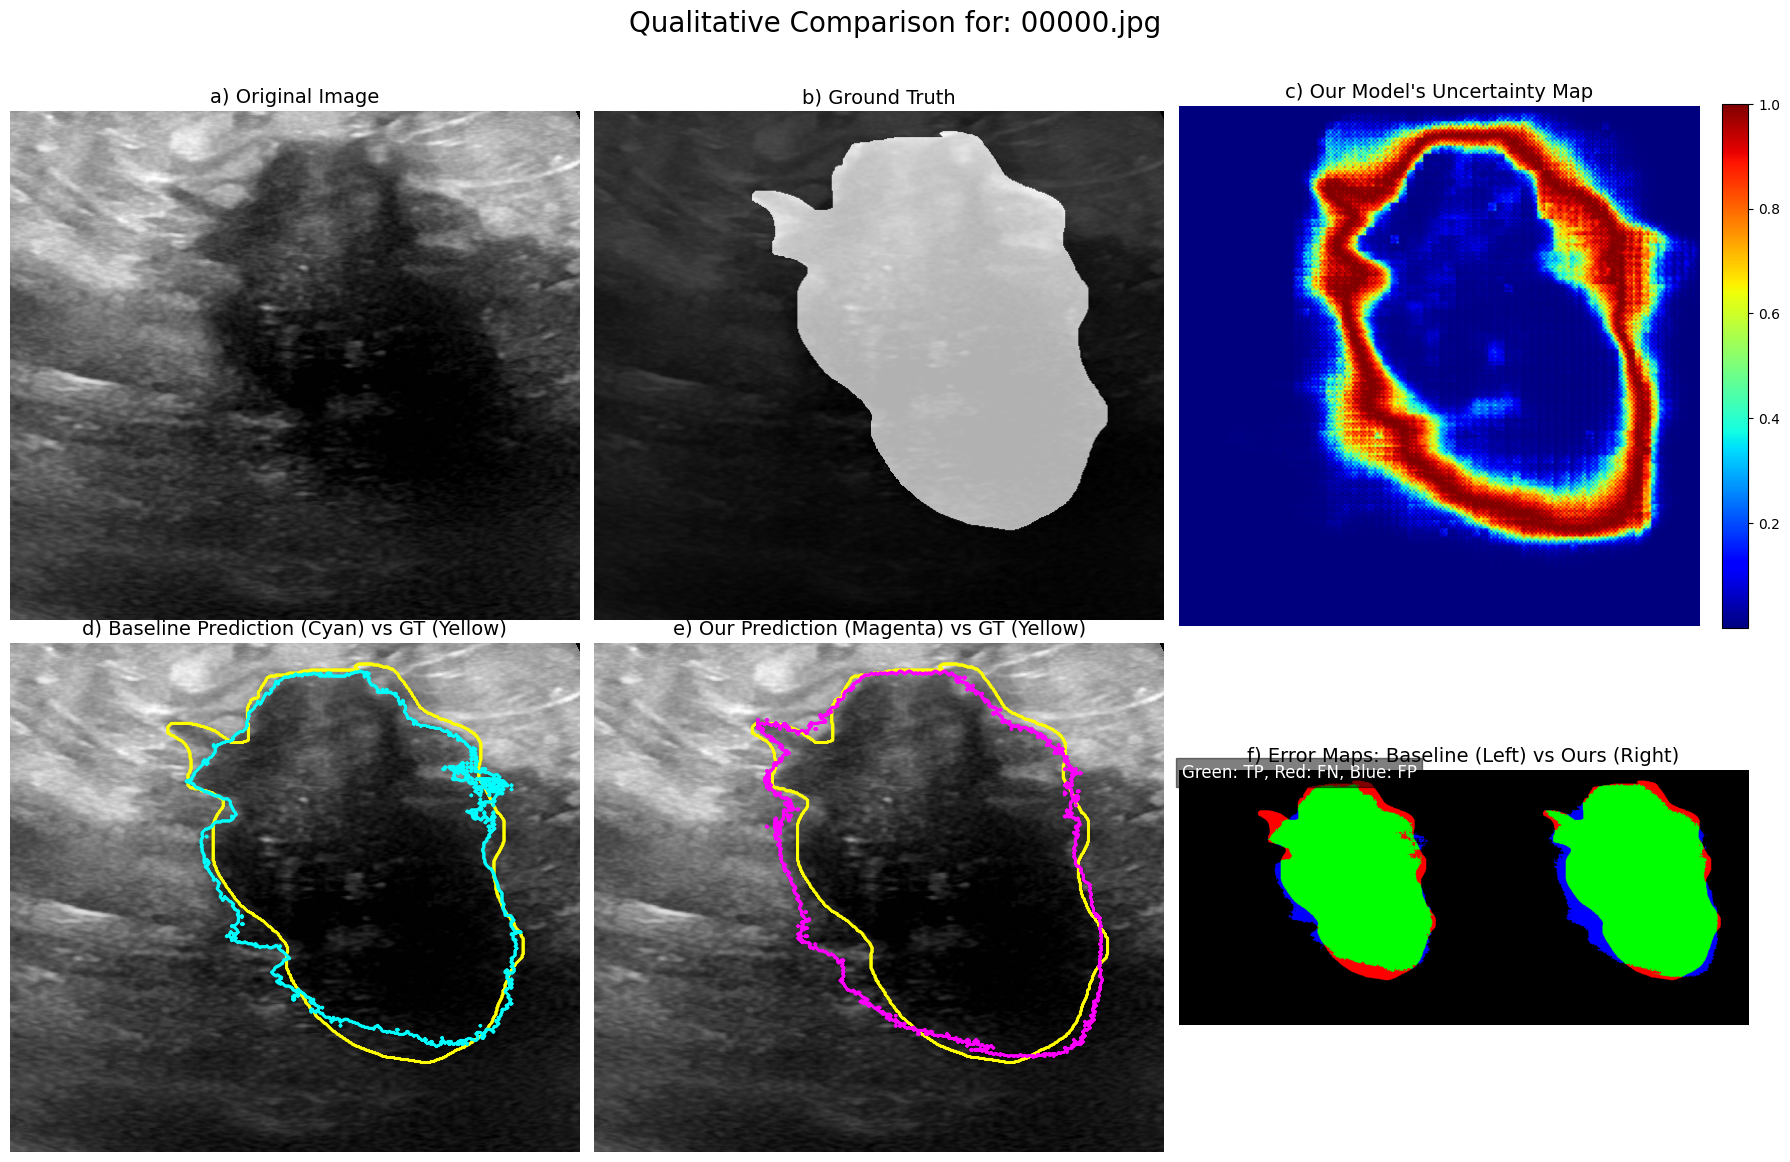

Visualizing samples:  33%|███▎      | 1/3 [00:04<00:08,  4.22s/it]


--- Processing: malignant_187 ---
Running inference for Baseline Model...
Running inference for Our Model (Adapter + U-BL)...
Visualization saved to: visualizations/00000_comparison_v2.png


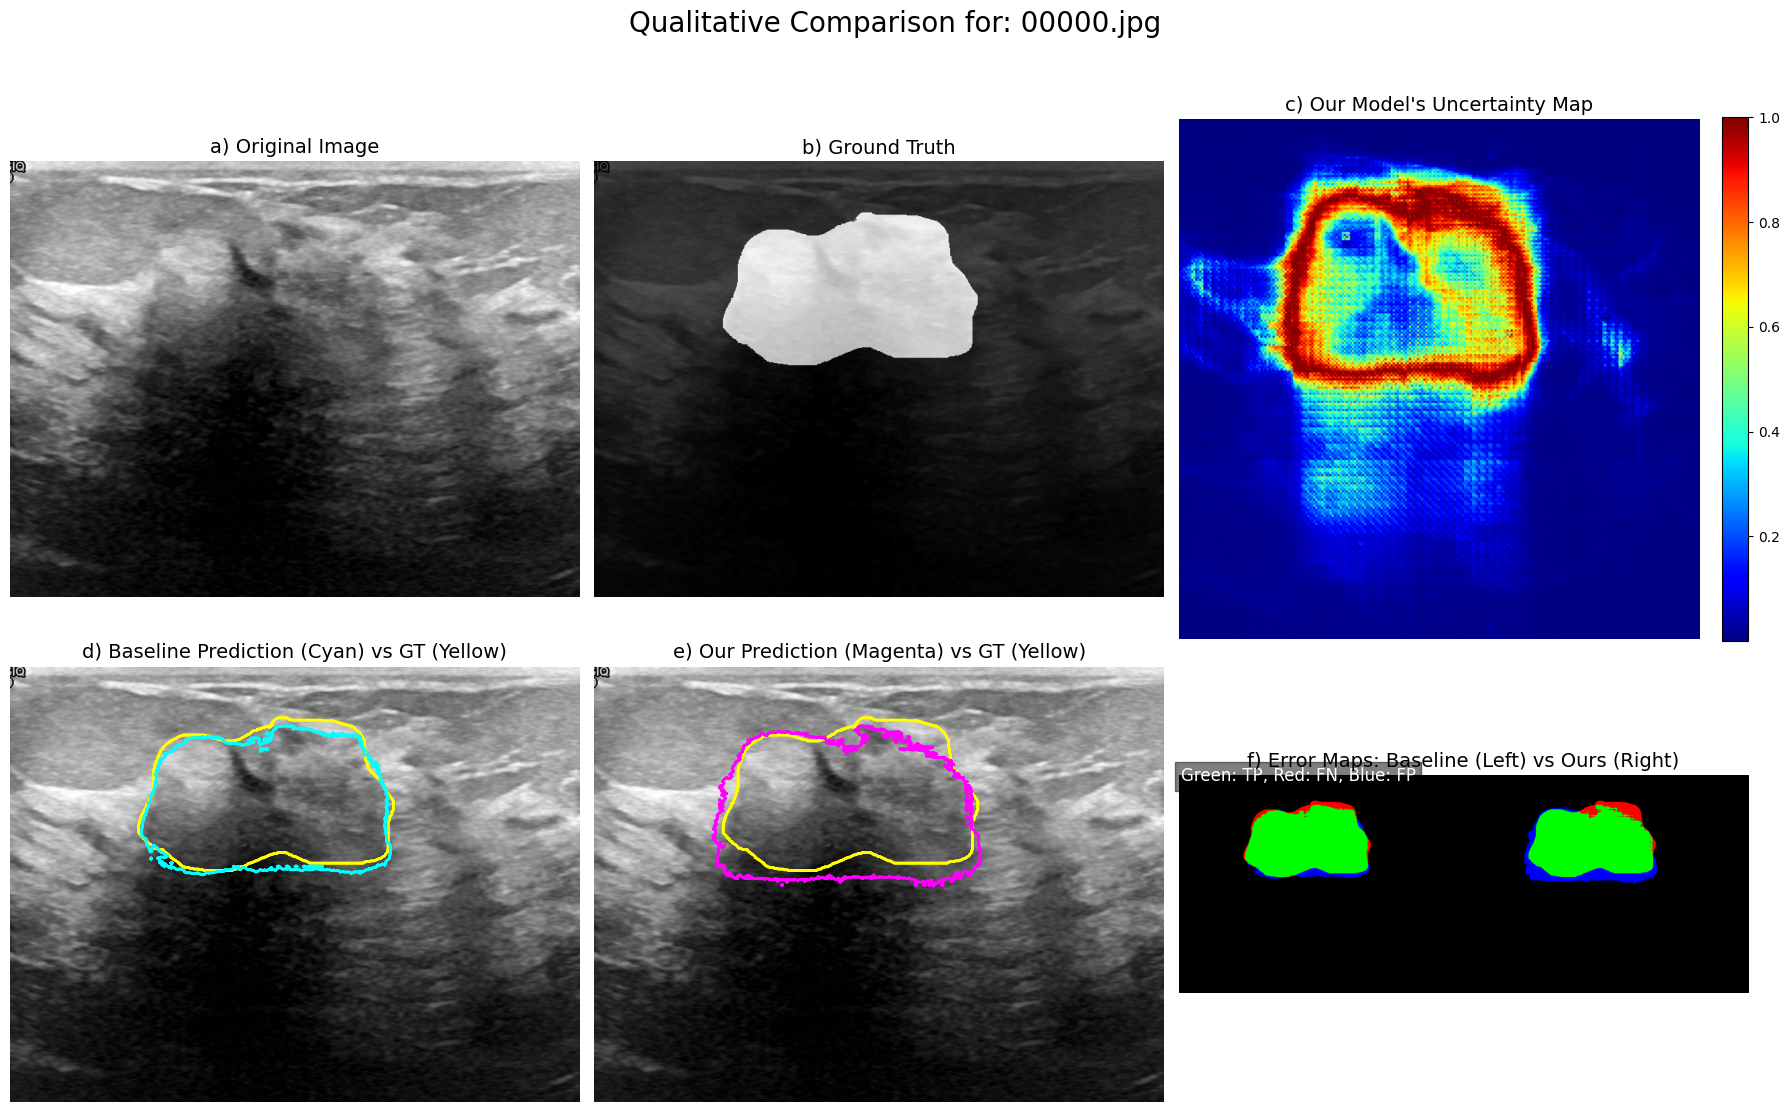

Visualizing samples:  67%|██████▋   | 2/3 [00:09<00:04,  4.60s/it]


--- Processing: malignant_188 ---
Running inference for Baseline Model...
Running inference for Our Model (Adapter + U-BL)...
Visualization saved to: visualizations/00000_comparison_v2.png


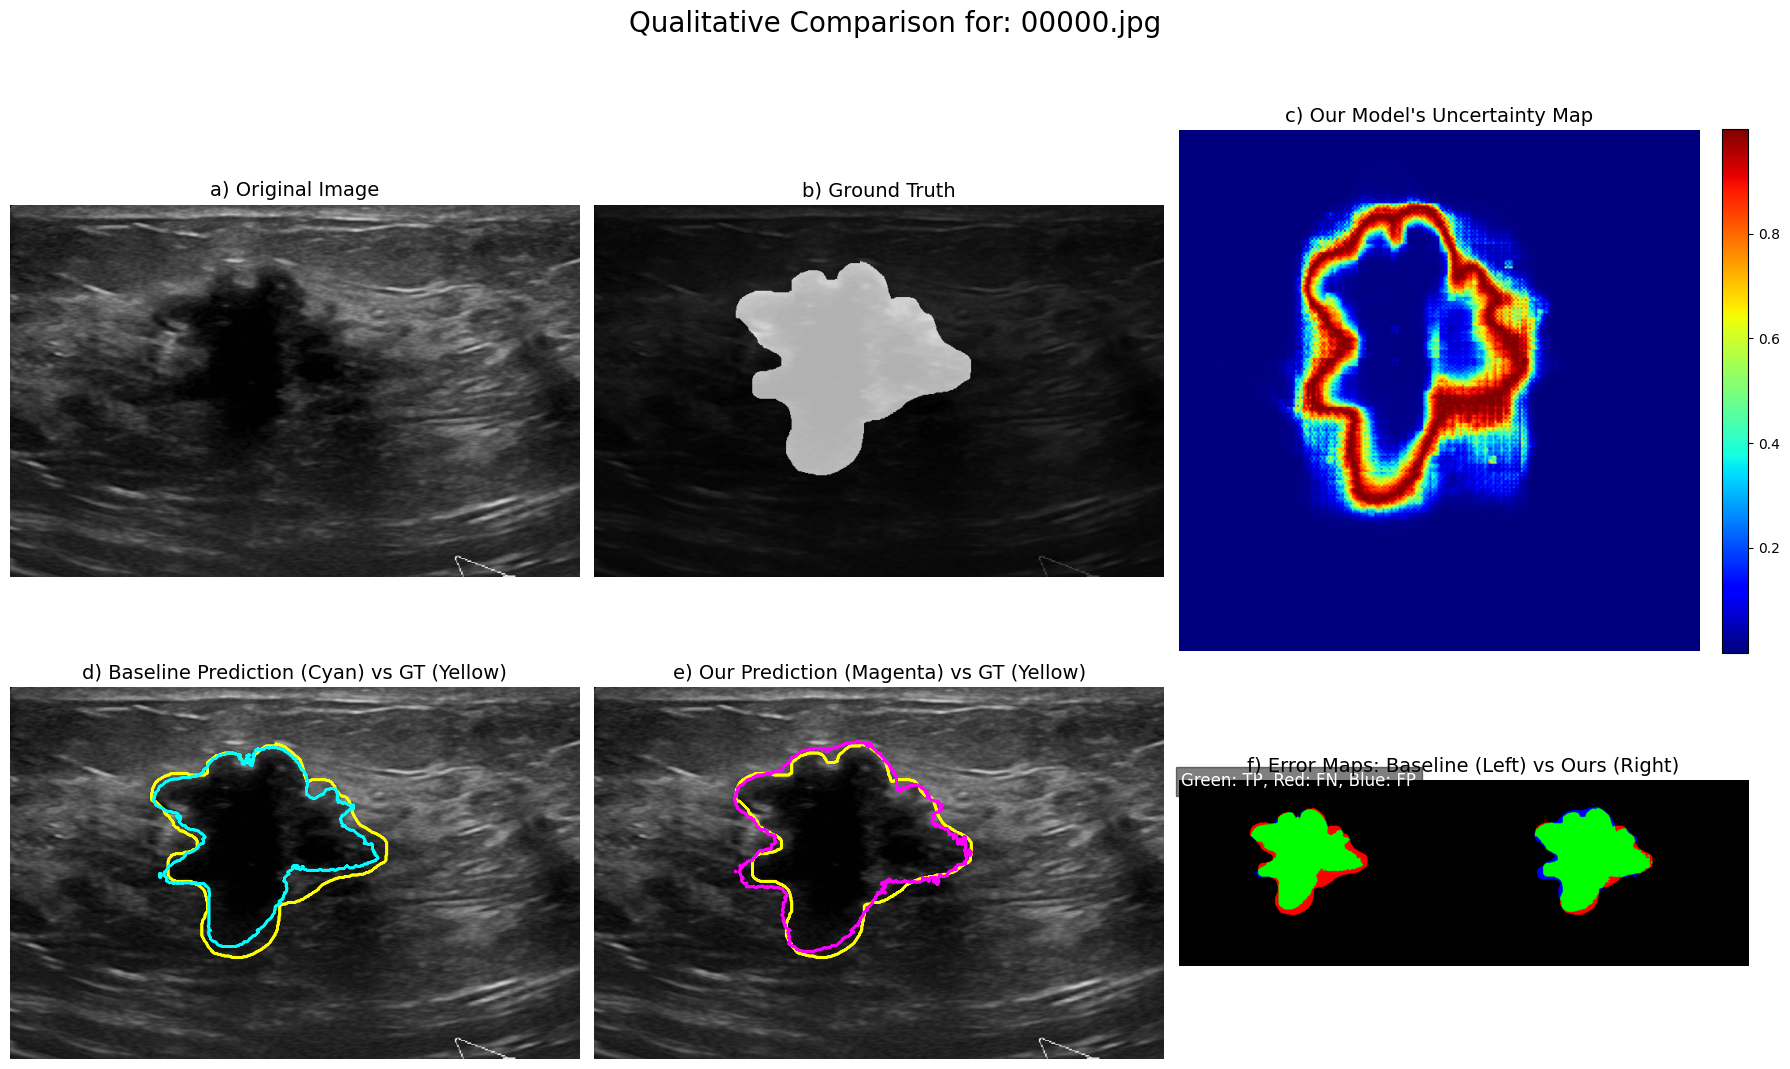

Visualizing samples: 100%|██████████| 3/3 [00:13<00:00,  4.47s/it]


Visualization process complete!


In [5]:
import os
import cv2
import numpy as np
import pandas as pd
import torch
from tqdm import tqdm

# ==============================================================================
# 关键：导入您需要的SAM2模型构建和预测工具
# ==============================================================================
from sam2.build_sam import build_sam2
from sam2.sam2_image_predictor import SAM2ImagePredictor

# ==============================================================================
# --- 1. 配置 (您需要在这里指定要评估哪个模型) ---
# ==============================================================================
# SAM2 Hydra 配置名
SAM2_CFG_NAME = "configs/sam2.1/sam2.1_hiera_b+"

# !! 修改这里，指向您想要评估的模型的检查点文件 !!
# 例如，可以是您的Adapter Baseline，也可以是某个runX的U-BL实验结果
SAM2_CHECKPOINT_PATH = "/path/to/your/chosen_run/checkpoints/checkpoint.pt" 

# 数据集路径 (通常无需修改)
SPLIT_DATASET_ROOT = "/home/zhengsongming/jupyterworkspace/datasets/BUSI_for_SAM2"
TEST_SET_FILE = os.path.join(SPLIT_DATASET_ROOT, "ImageSets/2017/val.txt")


# ==============================================================================
# --- 2. 指标计算函数 (已升级) ---
# ==============================================================================
def calculate_metrics(gt_mask, pred_mask):
    """
    计算Dice, IoU, Precision (精确率), 和 Recall (召回率)。
    """
    # 确保掩码是布尔类型或0/1的二值图像
    gt_mask_bool = gt_mask > 0
    pred_mask_bool = pred_mask > 0
    
    # 计算交集、并集等基础数值
    intersection = np.logical_and(gt_mask_bool, pred_mask_bool).sum()
    gt_sum = gt_mask_bool.sum()
    pred_sum = pred_mask_bool.sum()

    # Dice系数: 2 * |A ∩ B| / (|A| + |B|)
    dice = (2. * intersection) / (gt_sum + pred_sum + 1e-8)
    # IoU: |A ∩ B| / |A ∪ B|
    iou = intersection / (gt_sum + pred_sum - intersection + 1e-8)
    
    # Precision: TP / (TP + FP) = intersection / pred_sum
    # 精确率: 预测为正的样本中，有多少是真的正样本
    precision = intersection / (pred_sum + 1e-8)
    
    # Recall: TP / (TP + FN) = intersection / gt_sum
    # 召回率: 所有真的正样本中，有多少被成功预测出来了
    recall = intersection / (gt_sum + 1e-8)
    
    return dice, iou, precision, recall # <-- 返回所有四个指标


# ==============================================================================
# --- 3. 主评估流程 (核心逻辑) ---
# ==============================================================================
def main():
    # --- 模型加载 ---
    print("Loading SAM2 model in Adapter mode...")
    device = "cuda" if torch.cuda.is_available() else "cpu"
    
    HYDRA_OVERRIDES = [
        "model.image_encoder.trunk._target_=sam2.modeling.backbones.hieradet_adapter.HieraAdapter",
        "+model.image_encoder.trunk.use_adapter=True",
        "+model.use_adapter=True",
    ]

    model = build_sam2(
        SAM2_CFG_NAME, 
        SAM2_CHECKPOINT_PATH, 
        device=device,
        hydra_overrides_extra=HYDRA_OVERRIDES
    )
    predictor = SAM2ImagePredictor(model)
    print(f"Model and Predictor loaded on {device} from: {SAM2_CHECKPOINT_PATH}")

    # --- 数据集文件读取 ---
    if not os.path.exists(TEST_SET_FILE):
        raise FileNotFoundError(f"测试集定义文件未找到: {TEST_SET_FILE}")

    with open(TEST_SET_FILE, 'r') as f:
        test_sample_names = [line.strip() for line in f.readlines()]
    
    print(f"\nFound {len(test_sample_names)} samples in the test set. Starting evaluation...")
    
    results = []
    images_dir = os.path.join(SPLIT_DATASET_ROOT, "JPEGImages")
    annotations_dir = os.path.join(SPLIT_DATASET_ROOT, "Annotations")

    # --- 遍历测试集并进行推理评估 ---
    for sample_name in tqdm(test_sample_names, desc="Evaluating Test Set"):
        image_path = os.path.join(images_dir, sample_name, "00000.jpg")
        mask_path = os.path.join(annotations_dir, sample_name, "00000.png")
        
        if not os.path.exists(image_path) or not os.path.exists(mask_path):
            continue

        image = cv2.imread(image_path)
        image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
        gt_mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

        predictor.set_image(image_rgb)
        contours, _ = cv2.findContours(gt_mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        if not contours:
            continue
        
        largest_contour = max(contours, key=cv2.contourArea)
        x, y, w, h = cv2.boundingRect(largest_contour)
        box_prompt = np.array([[x, y, x + w, y + h]])

        masks, _, _ = predictor.predict(box=box_prompt, multimask_output=False)
        pred_mask = (masks[0] * 255).astype(np.uint8)
        
        # 计算所有四个指标
        dice, iou, precision, recall = calculate_metrics(gt_mask, pred_mask)
        
        category = 'benign' if 'benign' in sample_name else 'malignant'
        
        # 将所有结果存入列表
        results.append({
            "category": category,
            "dice": dice,
            "iou": iou,
            "precision": precision,
            "recall": recall
        })

        predictor.reset_predictor()

    # --- 结果汇总与展示 ---
    if not results:
        print("No images were processed.")
        return

    df_results = pd.DataFrame(results)
    
    # 定义需要计算的统计量
    agg_functions = {
        'dice': ['mean', 'std'],
        'iou': ['mean', 'std'],
        'precision': ['mean', 'std'],
        'recall': ['mean', 'std'],
        'dice': ['count'] # 用dice列来计数
    }
    
    # 按类别进行分组统计
    summary = df_results.groupby('category').agg(agg_functions).round(4) # 保留4位小数
    
    print("\n" + "="*80)
    print("--- Evaluation Summary on Test Set (val.txt) ---")
    print("="*80)
    print(summary.to_string())
    print("="*80)

if __name__ == '__main__':
    main()